# How to read .fits files?

FITS (Flexible Image Transport System) is the data format most widely used within astronomy for transporting, analyzing, and archiving scientific data files. A data file in FITS format consists of a series of Header Data Units (HDUs), each containing two components: an ASCII text header and the binary data. The header contains a series of header keywords that describe the data in a particular HDU and the data component immediately follows the header.


### The following libraries are required
- astropy
- matplotlib
- numpy

The astropy.io.fits package handles the reading and writing of FITS files in Python.

**Example**

File name: toltec_simu_a1100_filtered.fits

Once the astropy.io.fits package is loaded we can open an existing FITS file: 

The open function returns an object called an HDUList which is a list-like collection of HDU objects. An HDU (Header Data Unit) is the highest level component of the FITS file structure, consisting of a header and (typically) a data array or table.

To get information about the contents of a FITS file, use the info() function. The info() function returns a structure containing the information about the file and detailed information about the data in the file.


In [37]:
import astropy.io.fits as ft # import the module
ff=ft.open("toltec_simu_a1100_filtered.fits") # To load a FITS file  
ff.info() # show the contents of the opened FITS file


Filename: toltec_simu_a1100_filtered.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      21   ()      
  1  signal_I      1 ImageHDU        34   (3714, 3708, 1, 1)   float64   
  2  weight_I      1 ImageHDU        34   (3714, 3708, 1, 1)   float64   
  3  kernel_I      1 ImageHDU        34   (3714, 3708, 1, 1)   float64   
  4  coverage_I    1 ImageHDU        34   (3714, 3708, 1, 1)   float64   
  5  sig2noise_I    1 ImageHDU        34   (3714, 3708, 1, 1)   float64   
  6  coverage_bool_I    1 ImageHDU        34   (3714, 3708, 1, 1)   float64   


As we can see, this file contains seven HDUs.
Each element of an HDUList is an HDU object with .header and .data attributes, which can be used to access the header and data portions of the HDU.
- If an HDU’s data is an image, the data attribute of the HDU object will return a numpy ndarray object. Refer to the numpy documentation for details on manipulating these numerical arrays:

In [32]:
ff[1].data # Here, data points to the data object in the second HDU signal_I

array([[[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]]]])

- Now, when we want to access a header, we use the .header method, which displays the cards it contains.Each of the header entries (cards) admits integer, string, float, etc.

So, this simple file contains just one HDU which has 34 entries in its header (cards) and data which has dimensions (3714, 3708, 1, 1).

In [9]:
ff[1].header # signal_I has 34 cards 

XTENSION= 'IMAGE   '           / IMAGE extension                                
BITPIX  =                  -64 / number of bits per data pixel                  
NAXIS   =                    4 / number of data axes                            
NAXIS1  =                 3714 / length of data axis 1                          
NAXIS2  =                 3708 / length of data axis 2                          
NAXIS3  =                    1 / length of data axis 3                          
NAXIS4  =                    1 / length of data axis 4                          
PCOUNT  =                    0 / required keyword; must = 0                     
GCOUNT  =                    1 / required keyword; must = 1                     
EXTNAME = 'signal_I'                                                            
HDUVERS =                    1                                                  
UNIT    = 'mJy/beam'           / Unit of map                                    
CTYPE1  = 'RA---TAN'        

To **display a figure**, it is essential to import the matplotlib library. The goal is to see the figure in 2D so for our file that contains four axes the last two will be assigned zero.

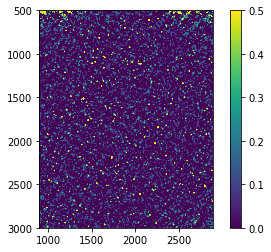

In [36]:
import matplotlib.pyplot as plt
plt.figure() 
plt.xlim(900, 2900) # x-axis limits
plt.ylim(3000, 500) # y-axis limits
plt.imshow(ff[1].data[0,0,:,:],vmin=0,vmax=0.5) # The last two will be assigned zero
plt.colorbar()

#### Working with Table Data

This section describes reading and writing table data in the FITS format using the fits package directly. FITS tables work like images, with multiple HDUs with their own headers and data.



**Example**

FILE NAME: sq0.01.pybdsm.srl.FITS


In [33]:
fa=ft.open("sq0.01.pybdsm.srl.FITS") # file open
fa.info() 

Filename: sq0.01.pybdsm.srl.FITS
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU    184   5892R x 45C   [J, J, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, A]   


Like images, the data portion of a FITS table extension is in the .data attribute. To see the second row (BinTableHDU) of the table:

In [20]:
fa[1].data # extension 1

FITS_rec([(   0,    0, 269.73556605, 5.79489744e-05, 1.34895906, 6.98025379e-05, 0.00120675, 0.00020856, 0.00120675, 0.00012407, 269.73556605, 5.79489744e-05, 1.34895906, 6.98025379e-05, 0.00138887, 0.00016437, 0.00138884, 0.00013646, 9.01800830e-03, 45.88185242, 0.0013889, 0.00016437, 0.0013889, 0.00013646, 0., 45.88185242, 0., 0.00016437, 0., 0.00013646, 0., 45.88185242, 0., 0.00016437, 0., 0.00013646, 0., 45.88185242,  0.00161979, 0.00026648, 0.00012156, 7.93904006e-06, 0.0001091 , 6.05060079e-05, 'C'),
          (   1,    0, 269.73471185, 7.13041711e-05, 1.34723221, 8.58895547e-05, 0.00098072, 0.00020856, 0.00098072, 0.00012407, 269.73471185, 7.13041711e-05, 1.34723221, 8.58895547e-05, 0.00138887, 0.00020225, 0.00138884, 0.00016791, 8.99789468e-03, 56.45389307, 0.0013889, 0.00020225, 0.0013889, 0.00016791, 0., 56.45389307, 0., 0.00020225, 0., 0.00016791, 0., 56.45389307, 0., 0.00020225, 0., 0.00016791, 0., 56.45389307,  0.00161979, 0.00026648, 0.00012156, 7.93904006e-06, 0.0001091 

Each of the columns represents something, to know the assigned name, use the columns function.

In [7]:
fa[1].data.columns 

ColDefs(
    name = 'Source_id'; format = 'J'
    name = 'Isl_id'; format = 'J'
    name = 'RA'; format = 'D'; unit = 'deg'
    name = 'E_RA'; format = 'D'; unit = 'deg'
    name = 'DEC'; format = 'D'; unit = 'deg'
    name = 'E_DEC'; format = 'D'; unit = 'deg'
    name = 'Total_flux'; format = 'D'; unit = 'Jy'
    name = 'E_Total_flux'; format = 'D'; unit = 'Jy'
    name = 'Peak_flux'; format = 'D'; unit = 'Jy/beam'
    name = 'E_Peak_flux'; format = 'D'; unit = 'Jy/beam'
    name = 'RA_max'; format = 'D'; unit = 'deg'
    name = 'E_RA_max'; format = 'D'; unit = 'deg'
    name = 'DEC_max'; format = 'D'; unit = 'deg'
    name = 'E_DEC_max'; format = 'D'; unit = 'deg'
    name = 'Maj'; format = 'D'; unit = 'deg'
    name = 'E_Maj'; format = 'D'; unit = 'deg'
    name = 'Min'; format = 'D'; unit = 'deg'
    name = 'E_Min'; format = 'D'; unit = 'deg'
    name = 'PA'; format = 'D'; unit = 'deg'
    name = 'E_PA'; format = 'D'; unit = 'deg'
    name = 'Maj_img_plane'; format = 'D'; unit = '

Now, to obtain the information of a specific row, it will be detailed to which extension and row you require.

In [22]:
fa[1].data[100] # extension 1, row 100

(100, 52, 269.7119890729436, 8.333526443518351e-05, 1.3447010163145763, 0.00010038137009984908, 0.0008391410513535208, 0.00020856453847912994, 0.0008391410513535208, 0.00012407352930787635, 269.7119890729436, 8.333526443518351e-05, 1.3447010163145763, 0.00010038137009984908, 0.001388872710876697, 0.00023637614096531516, 0.001388845440033978, 0.00019624280648308578, 0.008462522997192776, 65.97691983497297, 0.0013889, 0.00023637614096531516, 0.0013889, 0.00019624280648308578, 0.0, 65.97691983497297, 0.0, 0.00023637614096531516, 0.0, 0.00019624280648308578, 0.0, 65.97691983497297, 0.0, 0.00023637614096531516, 0.0, 0.00019624280648308578, 0.0, 65.97691983497297, 0.005110409062831248, 0.000444064914369602, 0.00012156488942710016, 7.939040059365028e-06, 9.336174827245173e-05, 6.645763177302364e-05, 'C')